# 🤖 Machine Learning — Live Coding Notebook
### Topics 13 & 14: Model Training, Evaluation & Interpretation

**How to use this notebook:** Run each cell top to bottom (click the cell, press **Shift + Enter**). Every section has:
- 🟦 a short **explanation**
- 💻 **simple code** you run in front of students
- 📊 a **result** (a number or a picture) to discuss
- ✍️ a small **"Your turn"** activity

Everything uses tiny, beginner-friendly datasets. No prior setup needed — just run.

---

## 0 · Setup — run this first
We import a few standard libraries. Run once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

np.random.seed(0)          # makes results repeatable
print(" Ready to go!")

 Ready to go!


---
## 1 · Parameters vs Hyperparameters

🟦 **The idea**
- **Trainable parameters** = values the model *learns from data* (e.g. the slope and intercept of a line).
- **Hyperparameters** = values *you choose before training* (e.g. how complex the model is).

Let's fit the simplest model — a straight line `y = w·x + b` — and read off the learned parameters.

In [2]:
from sklearn.linear_model import LinearRegression

# Tiny dataset: hours studied vs exam score
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)
scores = np.array([52, 55, 61, 65, 70, 74, 79, 85])

model = LinearRegression()
model.fit(hours, scores)          # <-- training happens here

print("LEARNED (trainable) parameters:")
print(f"   slope  w = {model.coef_[0]:.2f}")
print(f"   bias   b = {model.intercept_:.2f}")
print(f"\nSo the model learned:  score = {model.coef_[0]:.2f} * hours + {model.intercept_:.2f}")

LEARNED (trainable) parameters:
   slope  w = 4.70
   bias   b = 46.46

So the model learned:  score = 4.70 * hours + 46.46


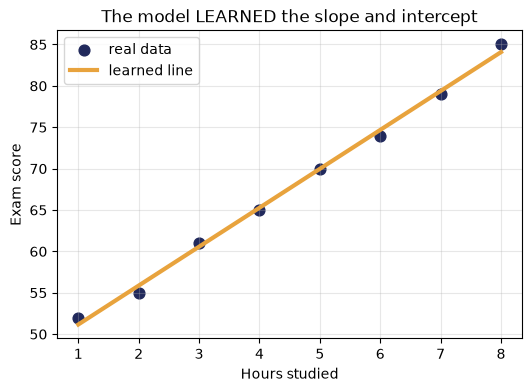

In [3]:
# See it as a picture
plt.figure(figsize=(6,4))
plt.scatter(hours, scores, color="#21295C", s=60, label="real data")
plt.plot(hours, model.predict(hours), color="#E8A33D", lw=3, label="learned line")
plt.xlabel("Hours studied"); plt.ylabel("Exam score")
plt.title("The model LEARNED the slope and intercept")
plt.legend(); plt.grid(alpha=.3); plt.show()

📊 **Discuss:** `w` and `b` were **learned** — we never typed them in. Those are *trainable parameters*.

A **hyperparameter** here would be *"should the line be straight or curved?"* — a choice **we** make. We explore exactly that next.

✍️ **Your turn:** Change one score in the `scores` array (say, make the last one `95`) and re-run. Watch the learned slope `w` change.

---
## 2 · Underfitting, Good fit, Overfitting

🟦 **The idea.** We fit curves of different **complexity** (the polynomial *degree* — a hyperparameter) to the same noisy data.
- **Degree too low** → too simple → **underfitting**
- **Degree just right** → **good fit**
- **Degree too high** → memorises the noise → **overfitting**

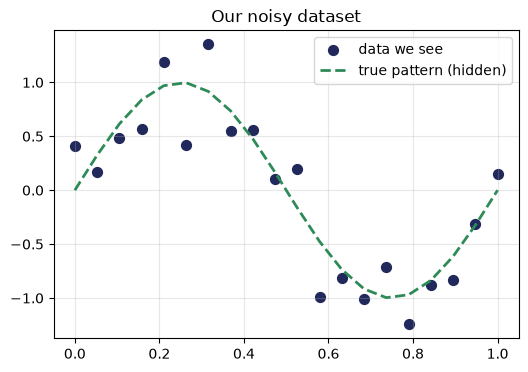

In [4]:
# Make simple noisy data from a gentle curve
np.random.seed(1)
X = np.linspace(0, 1, 20)
y_true = np.sin(2 * np.pi * X)              # the real hidden pattern
y = y_true + np.random.normal(0, 0.25, 20)  # add noise (real data is noisy)

plt.figure(figsize=(6,4))
plt.scatter(X, y, color="#21295C", s=50, label="data we see")
plt.plot(X, y_true, "--", color="#2E8B57", lw=2, label="true pattern (hidden)")
plt.legend(); plt.title("Our noisy dataset"); plt.grid(alpha=.3); plt.show()

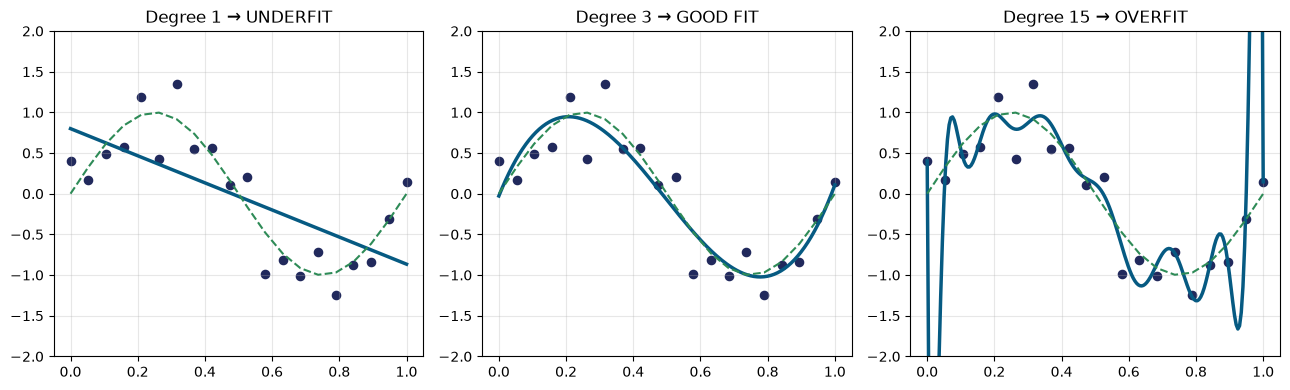

In [5]:
# Fit three models: degree 1 (simple), 3 (medium), 15 (very complex)
Xg = np.linspace(0, 1, 200)

plt.figure(figsize=(13,4))
for i, degree in enumerate([1, 3, 15]):
    coeffs = np.polyfit(X, y, degree)       # fit a polynomial
    y_pred = np.polyval(coeffs, Xg)

    plt.subplot(1, 3, i+1)
    plt.scatter(X, y, color="#21295C", s=35)
    plt.plot(Xg, y_pred, color="#065A82", lw=2.5)
    plt.plot(X, y_true, "--", color="#2E8B57", lw=1.5)
    plt.ylim(-2, 2)
    titles = {1:"Degree 1 → UNDERFIT", 3:"Degree 3 → GOOD FIT", 15:"Degree 15 → OVERFIT"}
    plt.title(titles[degree])
    plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

📊 **Discuss what students see:**
- **Degree 1:** a straight line that misses the curve — *too simple*.
- **Degree 3:** follows the true green pattern nicely — *just right*.
- **Degree 15:** wiggles through every point, chasing noise — *overfitting*.

✍️ **Your turn:** Add another degree to the list — try `[1, 3, 8, 15]` and change `plt.subplot(1, 3, ...)` to `plt.subplot(1, 4, ...)`. Which degree looks best to you?

In [6]:
# Prove it with NUMBERS: error on training points vs on NEW (test) points
X_test = np.linspace(0, 1, 20) + 0.001
y_test = np.sin(2*np.pi*X_test) + np.random.normal(0, 0.25, 20)

print(f"{'Degree':>7} | {'Train error':>12} | {'Test error':>11}")
print("-"*36)
for degree in [1, 3, 15]:
    coeffs = np.polyfit(X, y, degree)
    train_err = np.mean((np.polyval(coeffs, X)      - y)**2)
    test_err  = np.mean((np.polyval(coeffs, X_test) - y_test)**2)
    print(f"{degree:>7} | {train_err:>12.3f} | {test_err:>11.3f}")

 Degree |  Train error |  Test error
------------------------------------
      1 |        0.300 |       0.351
      3 |        0.087 |       0.036
     15 |        0.039 |       0.147


📊 **The key lesson (read the table):**
- Degree 1: both errors high → **underfitting**.
- Degree 3: both errors low → **good fit**.
- Degree 15: train error tiny, test error large → **overfitting** (memorised, didn't learn).

👉 The rule: **always compare training error with test error.** A big gap = overfitting.

---
## 3 · Bias and Variance

🟦 **The idea.**
- **Bias** = error from being *too simple* (underfitting). Falls as the model gets more complex.
- **Variance** = error from being *too sensitive* to the exact training data (overfitting). Rises with complexity.
- **Total error** is smallest in the middle — the **sweet spot**.

Let's *measure* variance directly: train the same model on different random samples and see how much its predictions jump around.

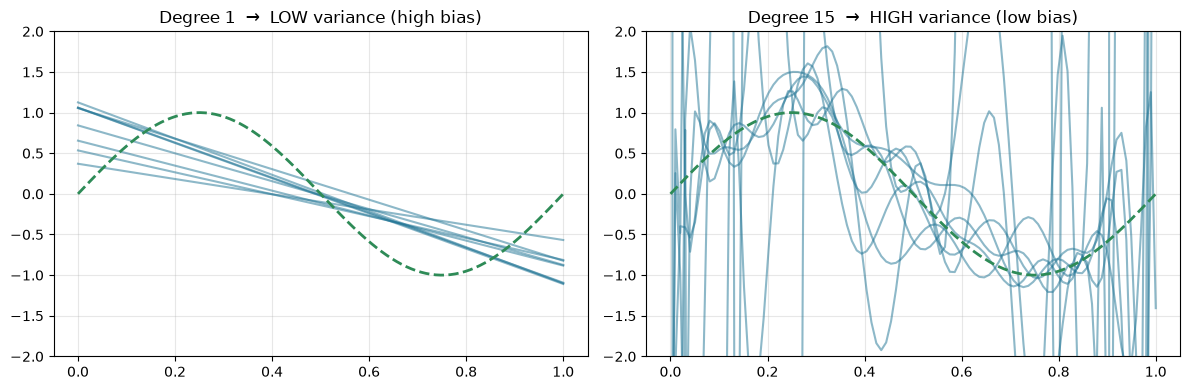

In [7]:
# Train a simple vs a complex model on 8 different random datasets
# and see how much the fitted curves DISAGREE (that disagreement = variance)
Xg = np.linspace(0, 1, 100)

plt.figure(figsize=(12,4))
for i, degree in enumerate([1, 15]):
    plt.subplot(1, 2, i+1)
    for _ in range(8):
        Xi = np.sort(np.random.rand(20))
        yi = np.sin(2*np.pi*Xi) + np.random.normal(0, 0.25, 20)
        coeffs = np.polyfit(Xi, yi, degree)
        plt.plot(Xg, np.polyval(coeffs, Xg), color="#1C7293", alpha=0.5)
    plt.plot(Xg, np.sin(2*np.pi*Xg), "--", color="#2E8B57", lw=2)
    plt.ylim(-2, 2)
    plt.title(f"Degree {degree}  →  {'LOW variance (high bias)' if degree==1 else 'HIGH variance (low bias)'}")
    plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

📊 **Discuss:**
- **Left (degree 1):** the 8 lines are almost identical — **low variance** — but all miss the curve — **high bias**.
- **Right (degree 15):** the 8 curves are wildly different each time — **high variance** — they overreact to noise.

That trade-off is the whole game: we want a model complex enough to capture the pattern, but not so complex it chases noise.

---
## 4 · Classification metrics (Accuracy, Precision, Recall, F1)

🟦 **The idea.** For classification we compare predicted labels to true labels. We use the famous, tiny **Iris flower** dataset (150 flowers, 3 species).

First the golden rule: **train on one part, test on another** (never grade on data the model already saw).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = datasets.load_iris()
X, y = iris.data, iris.target
print("Dataset shape:", X.shape, "| classes:", iris.target_names)

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("Training flowers:", len(X_train), "| Test flowers:", len(X_test))

clf = DecisionTreeClassifier(max_depth=3, random_state=0)   # max_depth is a HYPERPARAMETER
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("\nPredicted labels:", y_pred)
print("True labels:     ", y_test)

Dataset shape: (150, 4) | classes: ['setosa' 'versicolor' 'virginica']
Training flowers: 105 | Test flowers: 45

Predicted labels: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0]
True labels:      [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0]


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred, average='macro'), 3))
print("Recall   :", round(recall_score(y_test, y_pred, average='macro'), 3))
print("F1 score :", round(f1_score(y_test, y_pred, average='macro'), 3))

Accuracy : 0.978
Precision: 0.972
Recall   : 0.981
F1 score : 0.976


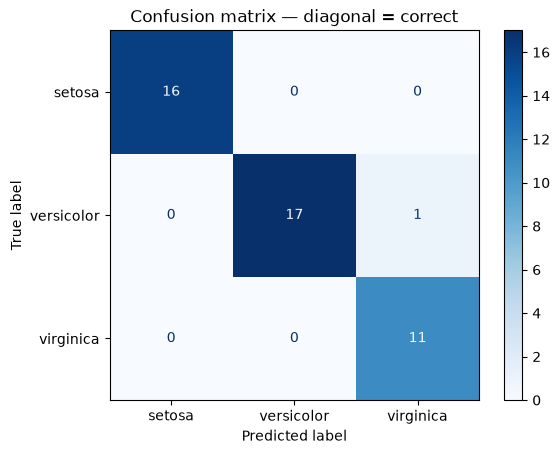

In [10]:
# The confusion matrix as a picture — where does the model get confused?
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test,
        display_labels=iris.target_names, cmap="Blues")
plt.title("Confusion matrix — diagonal = correct"); plt.show()

📊 **Discuss:**
- **Accuracy** = overall fraction correct.
- **Precision** = when it says a class, how often is it right?
- **Recall** = of all real members of a class, how many did it catch?
- **F1** = balance of precision and recall.
- The **confusion matrix** shows exactly which flowers get mixed up (off-diagonal cells).

✍️ **Your turn:** Change `max_depth=3` to `max_depth=1` and re-run. Accuracy drops — the tree is now too simple (**underfitting**).

---
## 5 · Regression metrics (MAE, MSE, RMSE, R²)

🟦 **The idea.** For regression we predict a *number*, so we measure *how far off* we are. We use the small **diabetes** dataset built into scikit-learn.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dia = datasets.load_diabetes()
X, y = dia.data, dia.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}   (average absolute error)")
print(f"MSE  = {mse:.2f}   (squared error)")
print(f"RMSE = {rmse:.2f}   (same units as target)")
print(f"R2   = {r2:.3f}    (1.0 = perfect, 0 = no better than the mean)")

MAE  = 44.62   (average absolute error)
MSE  = 3097.12   (squared error)
RMSE = 55.65   (same units as target)
R2   = 0.393    (1.0 = perfect, 0 = no better than the mean)


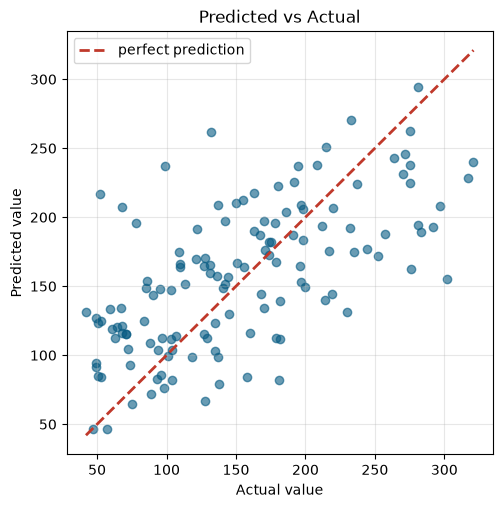

In [12]:
# Picture: predicted vs actual. Perfect predictions sit on the red line.
plt.figure(figsize=(5.5,5.5))
plt.scatter(y_test, y_pred, color="#065A82", alpha=.6)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "--", color="#C0392B", lw=2, label="perfect prediction")
plt.xlabel("Actual value"); plt.ylabel("Predicted value")
plt.title("Predicted vs Actual"); plt.legend(); plt.grid(alpha=.3); plt.show()

📊 **Discuss:** points near the red dashed line = good predictions. **RMSE** is the most useful to report because it's in the *same units* as the target. Notice **RMSE > MAE** — big errors get punished harder by squaring.

✍️ **Your turn:** Print `reg.coef_`. These 10 numbers are the **learned parameters** — one weight per health measurement.

---
## 6 · Cross-Validation

🟦 **The idea.** A single train/test split gives *one* score that depends on luck. **K-fold cross-validation** splits the data into K parts, tests on each part in turn, and averages — a much more trustworthy estimate.

In [13]:
from sklearn.model_selection import cross_val_score

clf = DecisionTreeClassifier(max_depth=3, random_state=0)
scores = cross_val_score(clf, iris.data, iris.target, cv=5)   # 5-fold

print("Score on each of the 5 folds:", np.round(scores, 3))
print(f"\nAverage accuracy = {scores.mean():.3f}  (± {scores.std():.3f})")
print("\nReporting mean ± std is far more honest than a single split.")

Score on each of the 5 folds: [0.967 0.967 0.933 0.933 1.   ]

Average accuracy = 0.960  (± 0.025)

Reporting mean ± std is far more honest than a single split.


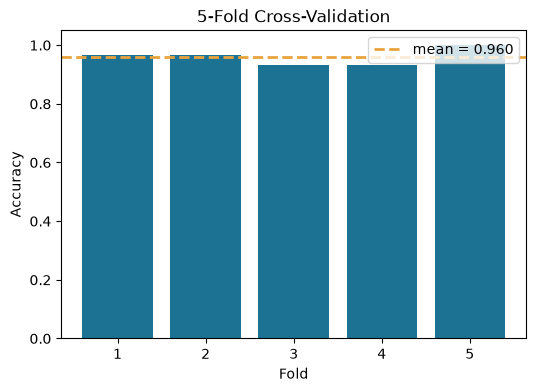

In [14]:
# Picture the 5 fold scores
plt.figure(figsize=(6,4))
plt.bar(range(1,6), scores, color="#1C7293")
plt.axhline(scores.mean(), color="#E8A33D", lw=2, ls="--", label=f"mean = {scores.mean():.3f}")
plt.ylim(0,1.05); plt.xlabel("Fold"); plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation"); plt.legend(); plt.show()

📊 **Discuss:** each bar is one fold's score; they differ — that's why one split alone can mislead. The gold line is the average we report.

✍️ **Your turn:** Change `cv=5` to `cv=10`. You now get 10 scores. Does the average change much?

---
## 7 · Interpretability — which features matter?

🟦 **The idea.** A model can be accurate but a "black box". **Interpretability** tells us *why* it decides. The simplest version is **feature importance**: how much each input influences the prediction.

(SHAP is the advanced, fair version of this idea. Below is the beginner-friendly built-in importance — same concept, no extra install.)

sepal length (cm)     : 0.000
sepal width (cm)      : 0.000
petal length (cm)     : 0.054
petal width (cm)      : 0.946


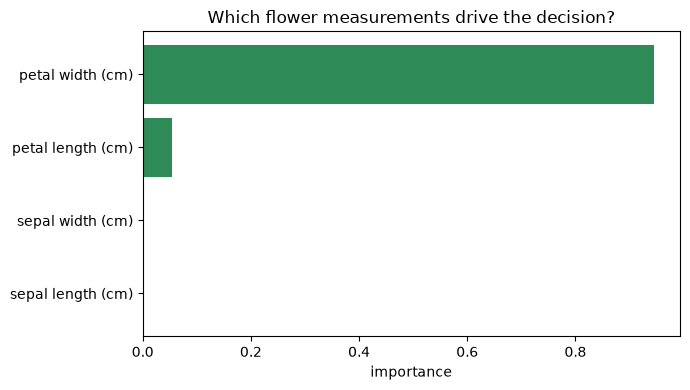

In [15]:
clf = DecisionTreeClassifier(max_depth=3, random_state=0)
clf.fit(iris.data, iris.target)

importances = clf.feature_importances_
for name, imp in zip(iris.feature_names, importances):
    print(f"{name:<22}: {imp:.3f}")

plt.figure(figsize=(7,4))
plt.barh(iris.feature_names, importances, color="#2E8B57")
plt.title("Which flower measurements drive the decision?")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

📊 **Discuss:** the longest bar is the feature the model relies on most. For iris, **petal** measurements usually dominate — that's an *insight about the real world*, not just the model.

**Optional — real SHAP** (only if you want to show the actual library; needs an install):

C:\Users\user\AppData\Local\Temp\ipykernel_7636\3414465380.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, iris.data, feature_names=iris.feature_names)
c:\ProgramData\anaconda3\envs\ml\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\ProgramData\anaconda3\envs\ml\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summa

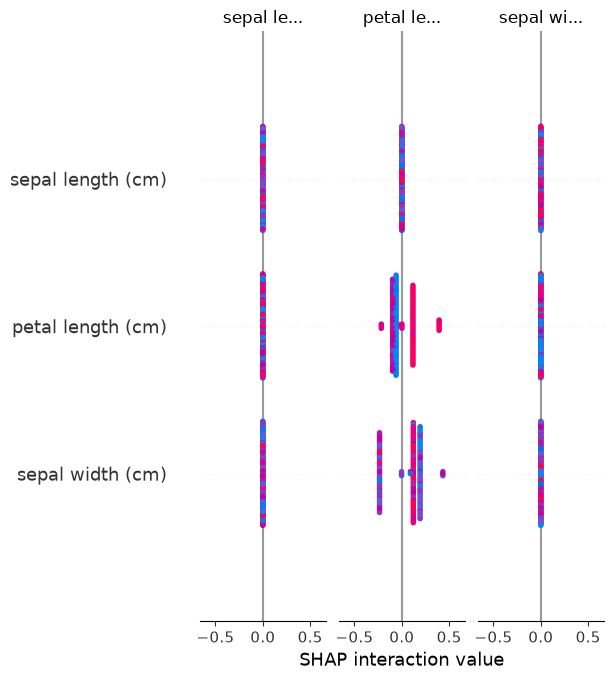

Feature importance above is the beginner version of the SHAP idea:
each feature gets 'credit' for how much it moves the prediction.


In [16]:
# OPTIONAL: uncomment the two lines below to run real SHAP in Colab
!pip install shap -q
import shap; explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(iris.data)
shap.summary_plot(shap_values, iris.data, feature_names=iris.feature_names)
print("Feature importance above is the beginner version of the SHAP idea:")
print("each feature gets 'credit' for how much it moves the prediction.")

---
## 8 · ✍️ Your Turn — Mini Coding Activity

Put it all together on the Iris dataset. Fill in the blanks (replace `____`) and run.

**Goal:** train a classifier, evaluate it properly, and read one metric.

In [ ]:
# ACTIVITY — fill in the blanks (____)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

X, y = datasets.load_iris(return_X_y=True)

# 1) Split the data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=____, random_state=0)

# 2) Create a k-NN model. n_neighbors is a HYPERPARAMETER — try 3.
model = KNeighborsClassifier(n_neighbors=____)

# 3) Train it
model.fit(____, ____)

# 4) Predict on the TEST set and print accuracy
y_pred = model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))

# 5) Now cross-validate with 5 folds and print the average
cv = cross_val_score(model, X, y, cv=____)
print("Cross-val average:", round(cv.mean(), 3))

<details>
<summary>✅ <b>Click for the solution</b></summary>

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
cv = cross_val_score(model, X, y, cv=5)
print("Cross-val average:", round(cv.mean(), 3))
```
</details>

**Challenge questions for students:**
1. Change `n_neighbors` to `1`, then to `50`. Which underfits, which overfits?
2. Which gives a more reliable score — the single split or the cross-validation average? Why?

---
## 🎉 Recap — what we coded today
| Concept | What we ran |
|---|---|
| Parameters vs hyperparameters | learned `w`, `b` of a line; chose `degree`, `max_depth`, `k` |
| Under / good / over-fitting | polynomial degree 1 / 3 / 15 |
| Bias & variance | 8 refits — low vs high disagreement |
| Train/test split | `train_test_split` |
| Classification metrics | accuracy, precision, recall, F1, confusion matrix |
| Regression metrics | MAE, MSE, RMSE, R² |
| Cross-validation | `cross_val_score`, 5 folds |
| Interpretability / SHAP | feature importance |

**Well done!** 🚀